In [1]:
!pip install scikit-learn -qq

# imports
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from functions import clean, split_data, train_and_test_model, evaluate_predictions

In [2]:
#load data
MRSA_df = pd.read_csv("MRSA_synthetic.csv")
VRE_df = pd.read_csv("VRE_synthetic.csv")
CRE_df = pd.read_csv("CRE_synthetic.csv")

#combine data
combined_df = pd.concat([MRSA_df, VRE_df, CRE_df], ignore_index=True)

#add clean text column
combined_df["text_clean"] = combined_df["clinical_report"].apply(clean)

In [3]:
# standardise labels and extraction columns
combined_df["label"] = combined_df["label"].fillna("NONE").astype(str).str.strip().str.upper()

combined_df["organism"] = combined_df["organism"].fillna("UNKNOWN").astype(str).str.strip().str.upper()
combined_df["antibiotic"] = combined_df["antibiotic"].fillna("UNKNOWN").astype(str).str.strip().str.upper()
combined_df["susceptibility"] = combined_df["susceptibility"].fillna("UNKNOWN").astype(str).str.strip().str.upper()

combined_df["clinical_report"] = combined_df["clinical_report"].fillna("").astype(str)
combined_df["text_clean"] = combined_df["text_clean"].fillna("").astype(str)

# collapse binary negatives into one final class
combined_df["label"] = combined_df["label"].replace({
    "NOT_MRSA": "NONE",
    "NOT_VRE": "NONE",
    "NOT_CRE": "NONE"
})


In [4]:
# checks
print("Label values:")
print(combined_df["label"].value_counts())

print("\nOrganism values:")
print(sorted(combined_df["organism"].dropna().unique()))

print("\nAntibiotic values:")
print(sorted(combined_df["antibiotic"].dropna().unique()))

print("\nSusceptibility values:")
print(sorted(combined_df["susceptibility"].dropna().unique()))

Label values:
label
NONE    700
MRSA    500
VRE     100
CRE     100
Name: count, dtype: int64

Organism values:
['ACHROMOBACTER XYLOSOXIDANS', 'BURKHOLDERIA VIETNAMIENSIS', 'CHRYSEOBACTERIUM INDOLOGENES', 'CITROBACTER FREUNDII', 'CITROBACTER FREUNDII COMPLEX', 'CITROBACTER KOSERI', 'COAG NEGATIVE STAPHYLOCOCCUS', 'CORYNEBACTERIUM SPECIES', 'ENTEROBACTER CLOACAE COMPLEX', 'ENTEROBACTER SPECIES', 'ENTEROCOCCUS FAECALIS', 'ENTEROCOCCUS FAECIUM', 'ENTEROCOCCUS FAECIUM -  VANCO RESISTANT', 'ENTEROCOCCUS SPECIES', 'ESCHERICHIA COLI', 'KLEBSIELLA AEROGENES', 'KLEBSIELLA OXYTOCA', 'KLEBSIELLA PNEUMONIAE', 'MORGANELLA MORGANII', 'MUCOID PSEUDOMONAS AERUGINOSA', 'MYCOBACTERIUM ABSCESSUS', 'MYCOBACTERIUM AVIUM COMPLEX', 'PROTEUS MIRABILIS', 'PROTEUS VULGARIS GROUP', 'PROVIDENCIA RETTGERI', 'PROVIDENCIA STUARTII', 'PSEUDOMONAS AERUGINOSA', 'PSEUDOMONAS AERUGINOSA (NON-MUCOID CF)', 'PSEUDOMONAS SPECIES - FLUORESCENS/PUTIDA GROUP', 'SERRATIA MARCESCENS', 'STAPH AUREUS {MRSA}', 'STAPH AUREUS(COLONY V

In [5]:
#split data
combined_train, combined_test = split_data(combined_df, label_col="label")

print("Train:", len(combined_train), "Test:", len(combined_test))
print("\nTrain label distribution:")
print(combined_train["label"].value_counts())

Train: 1120 Test: 280

Train label distribution:
label
NONE    560
MRSA    400
VRE      80
CRE      80
Name: count, dtype: int64


In [6]:
#raw text extraction models training

#organism
org_raw_model, org_raw_pred = train_and_test_model(
    combined_train, combined_test, "clinical_report", "organism"
)

#antibiotic
abx_raw_model, abx_raw_pred = train_and_test_model(
    combined_train, combined_test, "clinical_report", "antibiotic"
)

#susceptibility
sus_raw_model, sus_raw_pred = train_and_test_model(
    combined_train, combined_test, "clinical_report", "susceptibility"
)

#storing results
combined_test["pred_org_raw"] = org_raw_pred
combined_test["pred_abx_raw"] = abx_raw_pred
combined_test["pred_sus_raw"] = sus_raw_pred

In [7]:
#clean text extraction models training

#organism
org_clean_model, org_clean_pred = train_and_test_model(
    combined_train, combined_test, "text_clean", "organism"
)

#antibiotic
abx_clean_model, abx_clean_pred = train_and_test_model(
    combined_train, combined_test, "text_clean", "antibiotic"
)

#susceptibility
sus_clean_model, sus_clean_pred = train_and_test_model(
    combined_train, combined_test, "text_clean", "susceptibility"
)

#storing results
combined_test["pred_org_clean"] = org_clean_pred
combined_test["pred_abx_clean"] = abx_clean_pred
combined_test["pred_sus_clean"] = sus_clean_pred

Organism - Raw
Accuracy: 0.8607

Classification Report:
                                                                 precision    recall  f1-score   support

                                             CITROBACTER KOSERI       0.00      0.00      0.00         1
                                   COAG NEGATIVE STAPHYLOCOCCUS       0.98      0.98      0.98        44
                                        CORYNEBACTERIUM SPECIES       0.00      0.00      0.00         1
                                           ENTEROBACTER SPECIES       0.00      0.00      0.00         1
                                          ENTEROCOCCUS FAECALIS       1.00      0.43      0.60         7
                                           ENTEROCOCCUS FAECIUM       0.83      1.00      0.91        20
                                           ENTEROCOCCUS SPECIES       1.00      0.60      0.75         5
                                               ESCHERICHIA COLI       0.84      1.00      0.91        1

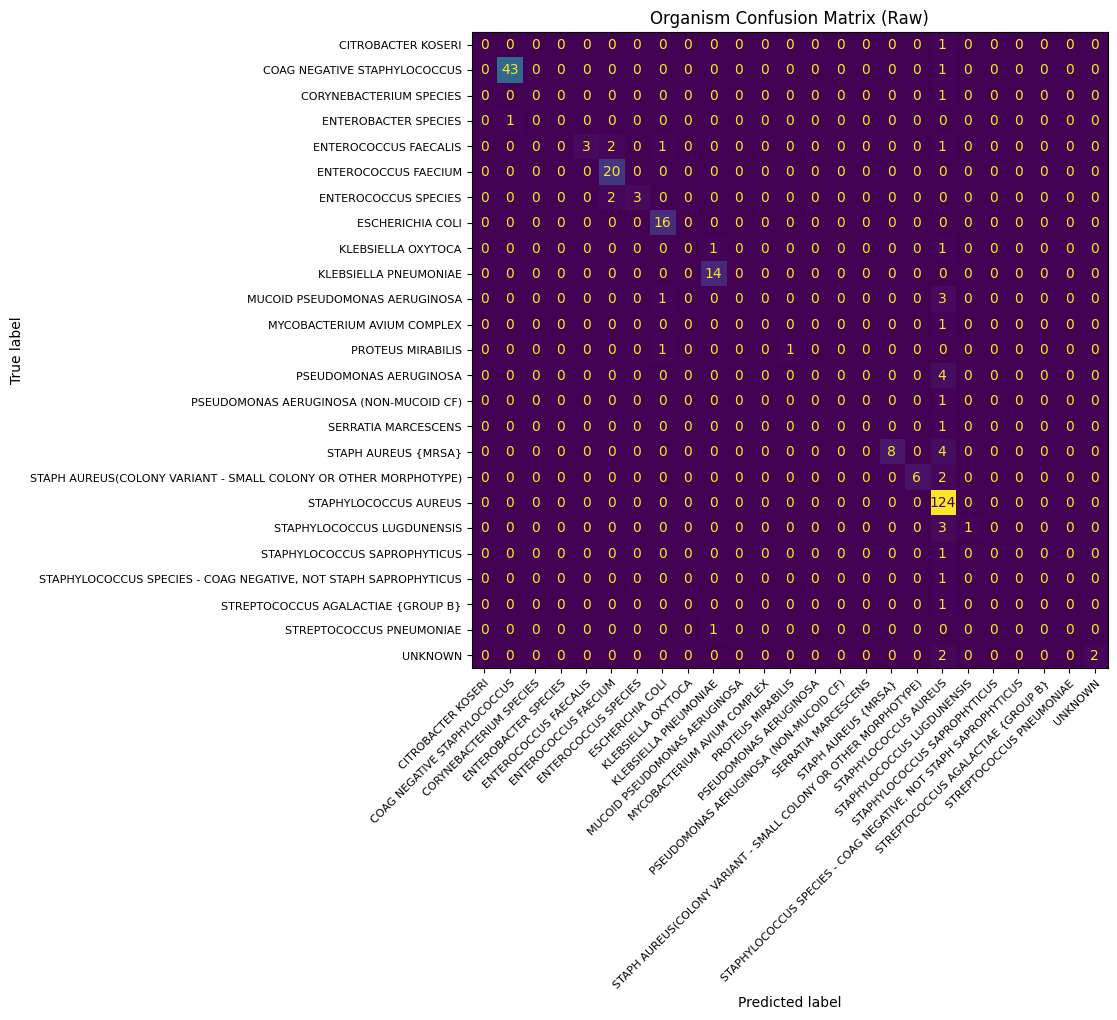


Number of errors: 39

First 10 error examples:
                                        clinical_report  \
908   Urine culture grew PSEUDOMONAS AERUGINOSA. cip...   
1146  Urine culture positive for E. SPECIES. vanc R....   
722   STAPH AUREUS {MRSA} isolated. oxa res. methici...   
1333  S. PNEUMONIAE isolated from blood cx. meropene...   
681   MSU positive for staphylococcus saprophyticus....   
1157  E. SPECIES grown, consistent with . vanc non-s...   
1352  pseudomonas aeruginosa (non-mucoid cf) grown, ...   
921   mycobacterium avium complex identified in sput...   
690   c.negativestaphylococcus identified in sputum ...   
1356  M. PSEUDOMONAS AERUGINOSA isolated; imi = non-...   

                                    organism           pred_org_raw  
908                   PSEUDOMONAS AERUGINOSA  STAPHYLOCOCCUS AUREUS  
1146                    ENTEROCOCCUS SPECIES   ENTEROCOCCUS FAECIUM  
722                      STAPH AUREUS {MRSA}  STAPHYLOCOCCUS AUREUS  
1333                ST

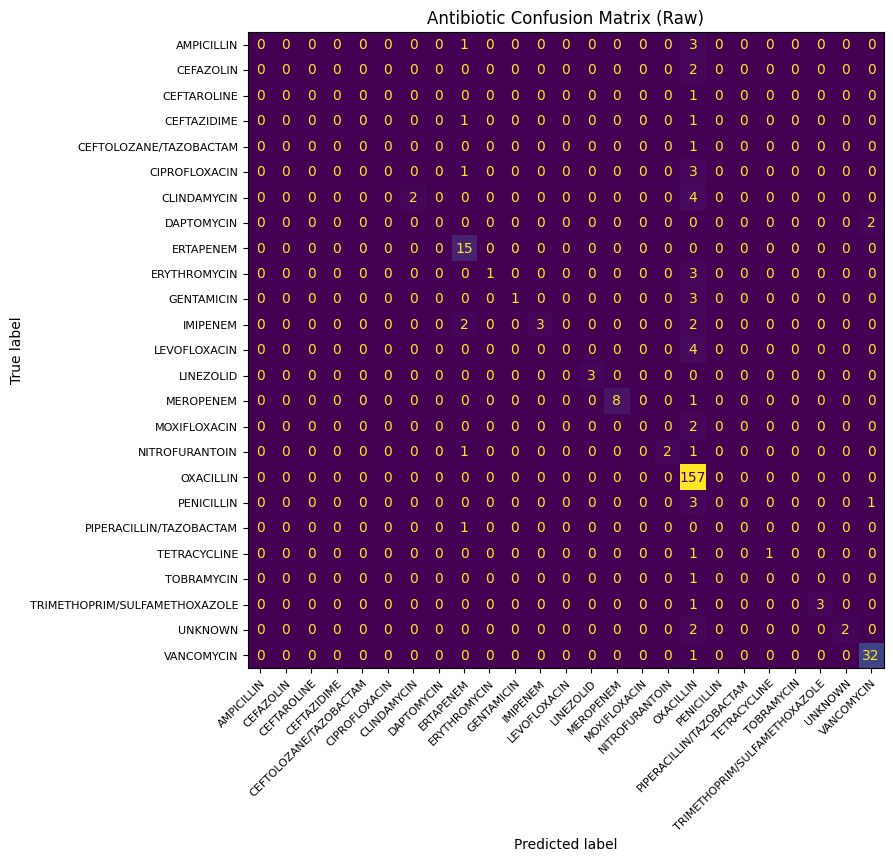


Number of errors: 50

First 10 error examples:
                                        clinical_report  \
908   Urine culture grew PSEUDOMONAS AERUGINOSA. cip...   
1263  Growth of klebsiella pneumoniae; imipenem non-...   
1187  ecoli recovered. Susceptibility: ampicillin se...   
1303  Escherichia coli isolated from catheter specim...   
995   Urine grew coliform, presumptive E. coli. ceft...   
944   e.species isolated from msu. cipro: intermediate.   
1352  pseudomonas aeruginosa (non-mucoid cf) grown, ...   
921   mycobacterium avium complex identified in sput...   
999   Klebsiella pneumoniae isolated from msu. tazoc...   
829   c.negativestaphylococcus identified in blood c...   

                   antibiotic pred_abx_raw  
908             CIPROFLOXACIN    OXACILLIN  
1263                 IMIPENEM    ERTAPENEM  
1187               AMPICILLIN    OXACILLIN  
1303            CIPROFLOXACIN    ERTAPENEM  
995               CEFTAZIDIME    OXACILLIN  
944             CIPROFLOXACIN   

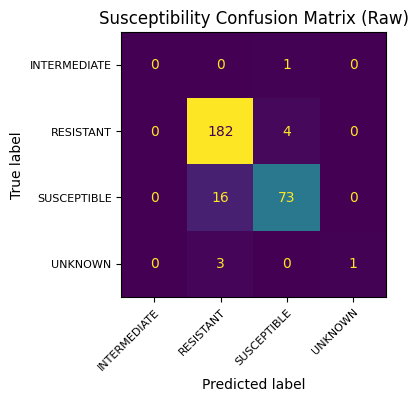


Number of errors: 24

First 10 error examples:
                                        clinical_report susceptibility  \
838   c.negativestaphylococcus grown, consistent wit...    SUSCEPTIBLE   
681   MSU positive for staphylococcus saprophyticus....    SUSCEPTIBLE   
944   e.species isolated from msu. cipro: intermediate.   INTERMEDIATE   
507   s.aureus identified in sputum culture; vancomi...    SUSCEPTIBLE   
999   Klebsiella pneumoniae isolated from msu. tazoc...    SUSCEPTIBLE   
829   c.negativestaphylococcus identified in blood c...      RESISTANT   
650   c.negativestaphylococcus grown, consistent wit...    SUSCEPTIBLE   
564          staph aureus cultured. gent reported as S.    SUSCEPTIBLE   
504            ET aspirate: MRSA isolated. oxacillin S.    SUSCEPTIBLE   
1183  Urine culture: e.coli isolated. tetracycline r...      RESISTANT   

     pred_sus_raw  
838     RESISTANT  
681     RESISTANT  
944   SUSCEPTIBLE  
507     RESISTANT  
999     RESISTANT  
829   SUSCEPTIBLE

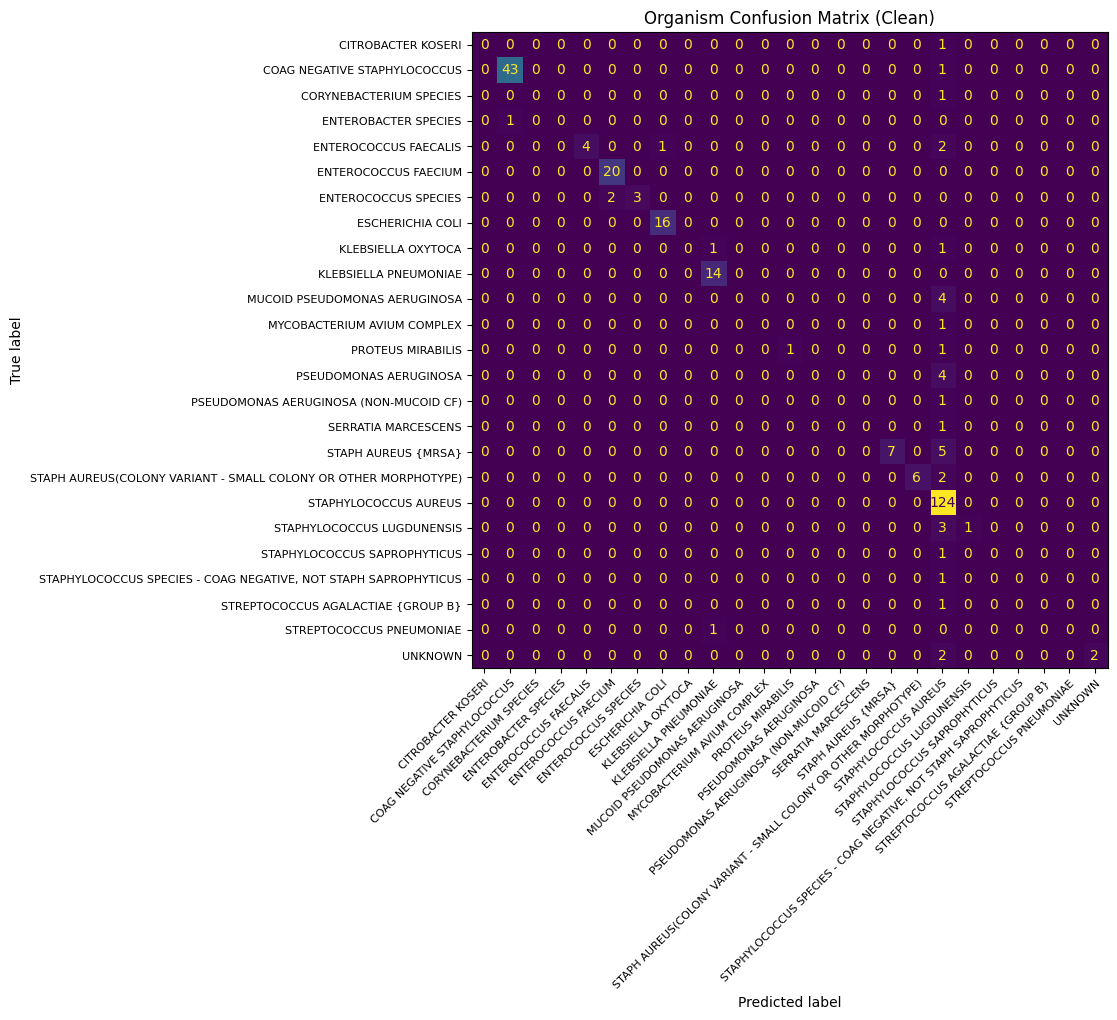


Number of errors: 39

First 10 error examples:
                                             text_clean  \
908   urine culture grew pseudomonas aeruginosa. cip...   
1146  urine culture positive for e. species. vancomy...   
722   staphylococcus aureus mrsa isolated. oxa resis...   
1333  susceptible. pneumoniae isolated from blood cx...   
681   msu positive for staphylococcus saprophyticus....   
1157  e. species grown consistent with . vancomycin ...   
1352  pseudomonas aeruginosa non-mucoid cf grown con...   
921   mycobacterium avium complex identified in sput...   
690   c.negativestaphylococcus identified in sputum ...   
1356  m. pseudomonas aeruginosa isolated imi non-sus...   

                                    organism         pred_org_clean  
908                   PSEUDOMONAS AERUGINOSA  STAPHYLOCOCCUS AUREUS  
1146                    ENTEROCOCCUS SPECIES   ENTEROCOCCUS FAECIUM  
722                      STAPH AUREUS {MRSA}  STAPHYLOCOCCUS AUREUS  
1333                ST

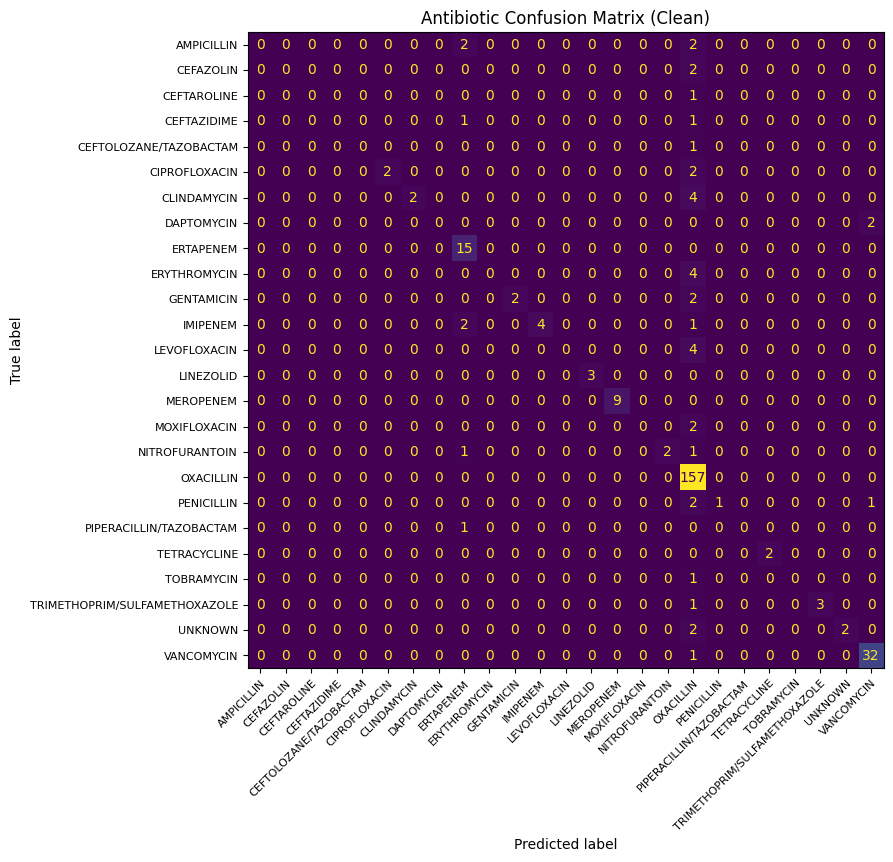


Number of errors: 44

First 10 error examples:
                                             text_clean  \
1263  growth of klebsiella pneumoniae imipenem non-s...   
1187  escherichia coli recovered. susceptibility amp...   
995   urine grew coliform presumptive escherichia co...   
944   e.species isolated from msu. ciprofloxacin int...   
921   mycobacterium avium complex identified in sput...   
999   klebsiella pneumoniae isolated from msu. tazoc...   
1252  msu klebsiella pneumoniae isolated. imipenem r...   
1164             growth of mrsa levofloxacin resistant.   
564   staphylococcus aureus cultured. gent reported ...   
528   staphylococcus aureus isolated possible pneumo...   

                   antibiotic pred_abx_clean  
1263                 IMIPENEM      ERTAPENEM  
1187               AMPICILLIN      ERTAPENEM  
995               CEFTAZIDIME      OXACILLIN  
944             CIPROFLOXACIN      OXACILLIN  
921              MOXIFLOXACIN      OXACILLIN  
999   PIPERACILLIN/T

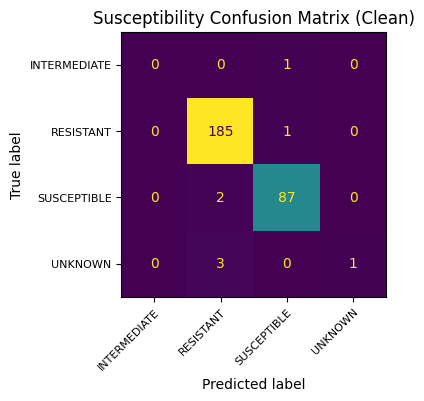


Number of errors: 7

First 7 error examples:
                                             text_clean susceptibility  \
944   e.species isolated from msu. ciprofloxacin int...   INTERMEDIATE   
509   methicillin resistant staphylococcus aureus gr...    SUSCEPTIBLE   
991                     isolated from sputum culture. .        UNKNOWN   
1168  urine grew susceptible. agalactiae group b . e...      RESISTANT   
901                             cultured. reported as .        UNKNOWN   
983             identified in catheter specimen urine .        UNKNOWN   
589   methicillin resistant staphylococcus aureus gr...    SUSCEPTIBLE   

     pred_sus_clean  
944     SUSCEPTIBLE  
509       RESISTANT  
991       RESISTANT  
1168    SUSCEPTIBLE  
901       RESISTANT  
983       RESISTANT  
589       RESISTANT  
          dataset version  accuracy  n_errors
0        Organism     Raw  0.860714        39
1      Antibiotic     Raw  0.821429        50
2  Susceptibility     Raw  0.914286        24
3

In [8]:
#evaluate extraction models

extraction_results = []

# raw

#organism
extraction_results.append(
    evaluate_predictions(combined_test, "organism", "pred_org_raw", "clinical_report", "Organism", "Raw")
)
#antibiotic
extraction_results.append(
    evaluate_predictions(combined_test, "antibiotic", "pred_abx_raw", "clinical_report", "Antibiotic", "Raw")
)
#susceptibility
extraction_results.append(
    evaluate_predictions(combined_test, "susceptibility", "pred_sus_raw", "clinical_report", "Susceptibility", "Raw")
)

# clean

#organism
extraction_results.append(
    evaluate_predictions(combined_test, "organism", "pred_org_clean", "text_clean", "Organism", "Clean")
)
#antibiotic
extraction_results.append(
    evaluate_predictions(combined_test, "antibiotic", "pred_abx_clean", "text_clean", "Antibiotic", "Clean")
)
#susceptibility
extraction_results.append(
    evaluate_predictions(combined_test, "susceptibility", "pred_sus_clean", "text_clean", "Susceptibility", "Clean")
)

extraction_results_df = pd.DataFrame(extraction_results)
print(extraction_results_df)

In [9]:
#rule based classifier

def rule_classify(organism: str, antibiotic: str, susceptibility: str) -> str:
    if pd.isna(organism) or pd.isna(antibiotic) or pd.isna(susceptibility):
        return "NONE"

    organism = str(organism).strip().upper()
    antibiotic = str(antibiotic).strip().upper()
    susceptibility = str(susceptibility).strip().upper()

    #defining rules using clinical logic decisions
    if (
        organism == "STAPHYLOCOCCUS AUREUS"
        and antibiotic in {"METHICILLIN", "METICILLIN", "OXACILLIN", "CEFOXITIN"}
        and susceptibility == "RESISTANT"
    ):
        return "MRSA"

    if (
        organism in {"ENTEROCOCCUS FAECALIS", "ENTEROCOCCUS FAECIUM"}
        and antibiotic == "VANCOMYCIN"
        and susceptibility == "RESISTANT"
    ):
        return "VRE"

    if (
        organism in {"ESCHERICHIA COLI", "KLEBSIELLA PNEUMONIAE"}
        and antibiotic in {"MEROPENEM", "IMIPENEM", "ERTAPENEM"}
        and susceptibility == "RESISTANT"
    ):
        return "CRE"

    return "NONE"

In [10]:
#apply rules

#to raw data extracted variables
combined_test["pred_label_rule_raw"] = combined_test.apply(
    lambda row: rule_classify(
        row["pred_org_raw"],
        row["pred_abx_raw"],
        row["pred_sus_raw"]
    ),
    axis=1
)

#to cleaned data extracted variables
combined_test["pred_label_rule_clean"] = combined_test.apply(
    lambda row: rule_classify(
        row["pred_org_clean"],
        row["pred_abx_clean"],
        row["pred_sus_clean"]
    ),
    axis=1
)

Rule-based final label - Raw
Accuracy: 0.8893

Classification Report:
              precision    recall  f1-score   support

         CRE       0.86      0.95      0.90        20
        MRSA       0.81      1.00      0.89       100
        NONE       0.99      0.79      0.88       140
         VRE       0.87      1.00      0.93        20

    accuracy                           0.89       280
   macro avg       0.88      0.93      0.90       280
weighted avg       0.91      0.89      0.89       280



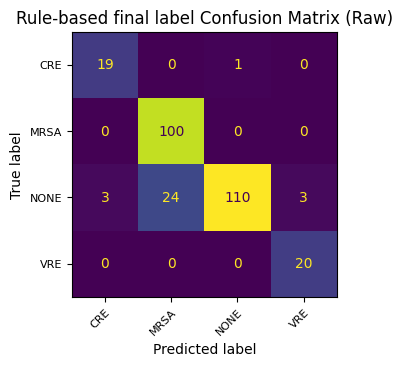


Number of errors: 31

First 10 error examples:
                                        clinical_report label  \
1146  Urine culture positive for E. SPECIES. vanc R....  NONE   
722   STAPH AUREUS {MRSA} isolated. oxa res. methici...  NONE   
681   MSU positive for staphylococcus saprophyticus....  NONE   
1157  E. SPECIES grown, consistent with . vanc non-s...  NONE   
1352  pseudomonas aeruginosa (non-mucoid cf) grown, ...  NONE   
921   mycobacterium avium complex identified in sput...  NONE   
999   Klebsiella pneumoniae isolated from msu. tazoc...  NONE   
1164                    Growth of MRSA; LEVOFLOXACIN R.  NONE   
564          staph aureus cultured. gent reported as S.  NONE   
504            ET aspirate: MRSA isolated. oxacillin S.  NONE   

     pred_label_rule_raw  
1146                 VRE  
722                 MRSA  
681                 MRSA  
1157                 VRE  
1352                MRSA  
921                 MRSA  
999                  CRE  
1164                

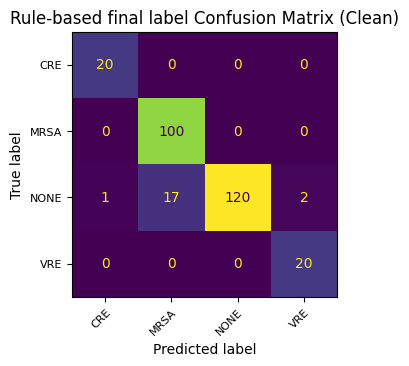


Number of errors: 20

First 10 error examples:
                                             text_clean label  \
1146  urine culture positive for e. species. vancomy...  NONE   
722   staphylococcus aureus mrsa isolated. oxa resis...  NONE   
1157  e. species grown consistent with . vancomycin ...  NONE   
921   mycobacterium avium complex identified in sput...  NONE   
1164             growth of mrsa levofloxacin resistant.  NONE   
702   susceptible. aureus mrsa identified in respira...  NONE   
509   methicillin resistant staphylococcus aureus gr...  NONE   
868   susceptible.species-coagnegative notstaphsapro...  NONE   
1165  susceptible. aureus isolated. penicillin resis...  NONE   
940   susceptible.marcescens recovered. susceptibili...  NONE   

     pred_label_rule_clean  
1146                   VRE  
722                   MRSA  
1157                   VRE  
921                   MRSA  
1164                  MRSA  
702                   MRSA  
509                   MRSA  
868 

In [11]:
#evaluate final rule labels
rule_results = []

#evaluation on rule based model that variables extracted from the raw data
rule_results.append(
    evaluate_predictions(combined_test, "label", "pred_label_rule_raw", "clinical_report", "Rule-based final label", "Raw")
)

#evaluation on rule based model that variables extracted from the clean data
rule_results.append(
    evaluate_predictions(combined_test, "label", "pred_label_rule_clean", "text_clean", "Rule-based final label", "Clean")
)

rule_results_df = pd.DataFrame(rule_results)
print(rule_results_df)

In [12]:
# create table for evaluation figures
extract_metrics = []

#function to store the evaluation scores
def store_extract_metrics(task, version, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    extract_metrics.append({
        "Task": task,
        "Text Version": version,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })


# extraction models - storing results for results table
store_extract_metrics("Organism", "Raw", combined_test["organism"], combined_test["pred_org_raw"])
store_extract_metrics("Organism", "Clean", combined_test["organism"], combined_test["pred_org_clean"])

store_extract_metrics("Antibiotic", "Raw", combined_test["antibiotic"], combined_test["pred_abx_raw"])
store_extract_metrics("Antibiotic", "Clean", combined_test["antibiotic"], combined_test["pred_abx_clean"])

store_extract_metrics("Susceptibility", "Raw", combined_test["susceptibility"], combined_test["pred_sus_raw"])
store_extract_metrics("Susceptibility", "Clean", combined_test["susceptibility"], combined_test["pred_sus_clean"])

# rule-based final label
store_extract_metrics("Rule-based final label", "Raw", combined_test["label"], combined_test["pred_label_rule_raw"])
store_extract_metrics("Rule-based final label", "Clean", combined_test["label"], combined_test["pred_label_rule_clean"])

# final table
extract_metrics_df = pd.DataFrame(extract_metrics).round(3)

# sort
order = ["Organism", "Antibiotic", "Susceptibility", "Rule-based final label"]
extract_metrics_df["Task"] = pd.Categorical(
    extract_metrics_df["Task"], categories=order, ordered=True
)
extract_metrics_df = extract_metrics_df.sort_values(by=["Task", "Text Version"])

print("\nExtraction and rule-based metrics:")
print(extract_metrics_df)

# save
extract_metrics_df.to_csv("extraction_rule_metrics.csv", index=False)


Extraction and rule-based metrics:
                     Task Text Version  Accuracy  Precision  Recall     F1
1                Organism        Clean     0.861      0.816   0.861  0.822
0                Organism          Raw     0.861      0.814   0.861  0.821
3              Antibiotic        Clean     0.843      0.787   0.843  0.795
2              Antibiotic          Raw     0.821      0.759   0.821  0.766
5          Susceptibility        Clean     0.975      0.972   0.975  0.970
4          Susceptibility          Raw     0.914      0.913   0.914  0.908
7  Rule-based final label        Clean     0.929      0.938   0.929  0.928
6  Rule-based final label          Raw     0.889      0.907   0.889  0.888


In [13]:
combined_test.to_csv("combined_extract.csv", index=False)

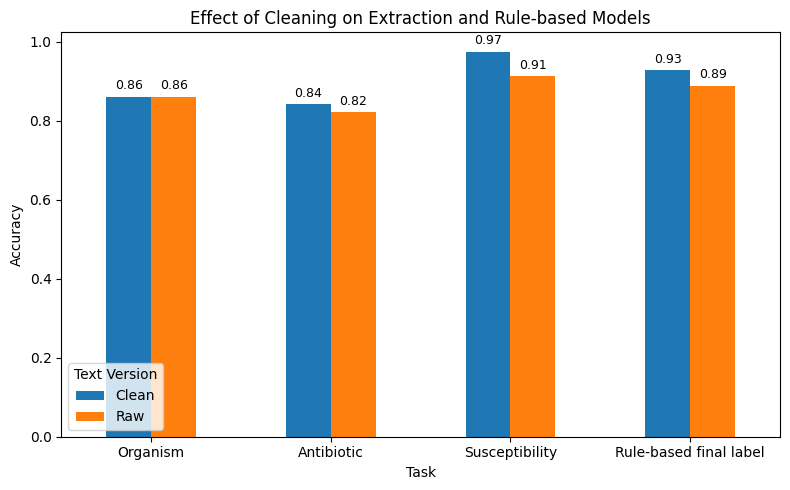

In [14]:
# combine extraction and rule-based classification
plot_pivot = extract_metrics_df.pivot(index="Task", columns="Text Version", values="Accuracy")

# set order
order = ["Organism", "Antibiotic", "Susceptibility", "Rule-based final label"]
plot_pivot = plot_pivot.reindex(order)

# plot
ax = plot_pivot.plot(
    kind="bar",
    figsize=(8, 5),
)

plt.title("Effect of Cleaning on Extraction and Rule-based Models")
plt.ylabel("Accuracy")
plt.xlabel("Task")
plt.xticks(rotation=0)

# add values on top
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9, padding=3)

plt.legend(title="Text Version", loc="lower left")
plt.tight_layout()
plt.show()

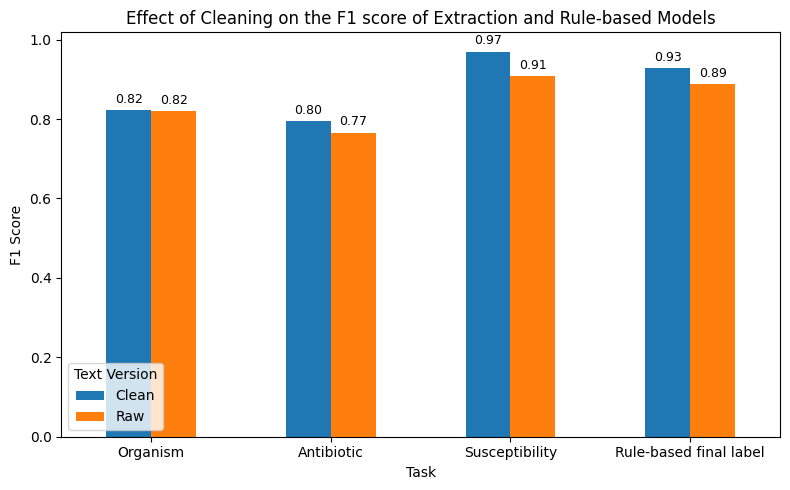

In [15]:
# combine extraction and rule-based classification
plot_pivot = extract_metrics_df.pivot(index="Task", columns="Text Version", values="F1")

# set order
order = ["Organism", "Antibiotic", "Susceptibility", "Rule-based final label"]
plot_pivot = plot_pivot.reindex(order)

# plot
ax = plot_pivot.plot(
    kind="bar",
    figsize=(8, 5),
)

plt.title("Effect of Cleaning on the F1 score of Extraction and Rule-based Models")
plt.ylabel("F1 Score")
plt.xlabel("Task")
plt.xticks(rotation=0)

# add values on top
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9, padding=3)

plt.legend(title="Text Version", loc="lower left")
plt.tight_layout()
plt.show()